# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-18] Epoch   1/100 | LR: 1.00e-04 | train loss 0.9420 acc 0.583 | val loss 0.6760 acc 0.710 *


[ResNet-18] Epoch   2/100 | LR: 1.00e-04 | train loss 0.5952 acc 0.754 | val loss 0.5692 acc 0.748 *


[ResNet-18] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4498 acc 0.787 | val loss 0.4478 acc 0.803 *


[ResNet-18] Epoch   4/100 | LR: 1.00e-04 | train loss 0.3833 acc 0.825 | val loss 0.5148 acc 0.792


...

[ResNet-18] Epoch  12/100 | LR: 1.00e-04 | train loss 0.2154 acc 0.905 | val loss 0.4241 acc 0.835


[ResNet-18] Epoch  13/100 | LR: 1.00e-04 | train loss 0.2409 acc 0.895 | val loss 0.3724 acc 0.843


[ResNet-18] Epoch  14/100 | LR: 1.00e-04 | train loss 0.1619 acc 0.931 | val loss 0.4346 acc 0.826


[ResNet-18] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1676 acc 0.930 | val loss 0.4574 acc 0.839


[ResNet-18] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1384 acc 0.944 | val loss 0.4149 acc 0.852

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 16.

[ResNet-18] Restored best checkpoint (val loss = 0.3609)


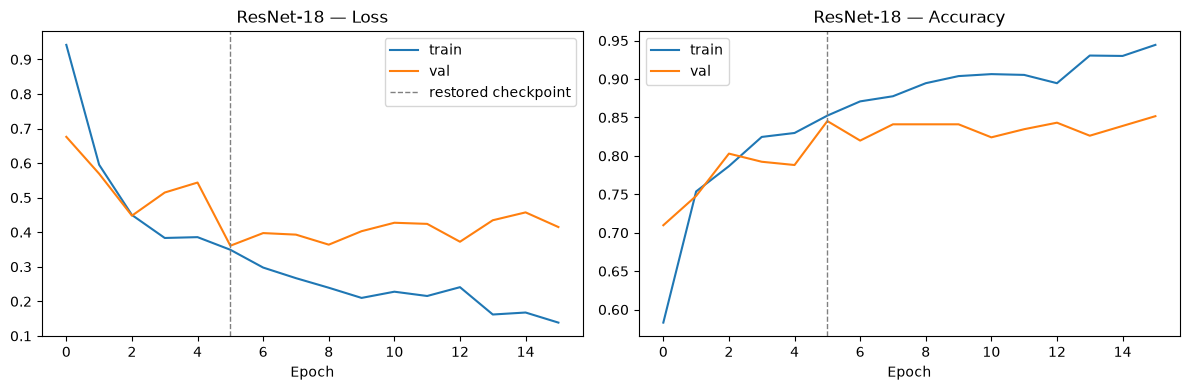

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.756


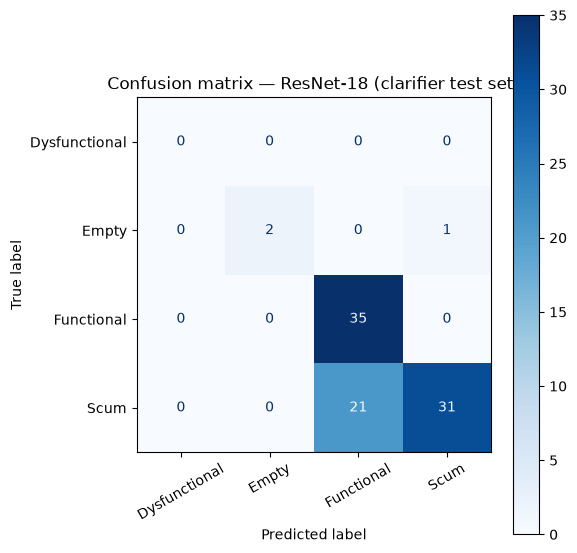

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      1.000     0.667     0.800         3
   Functional      0.625     1.000     0.769        35
         Scum      0.969     0.596     0.738        52

     accuracy                          0.756        90
    macro avg      0.648     0.566     0.577        90
 weighted avg      0.836     0.756     0.752        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


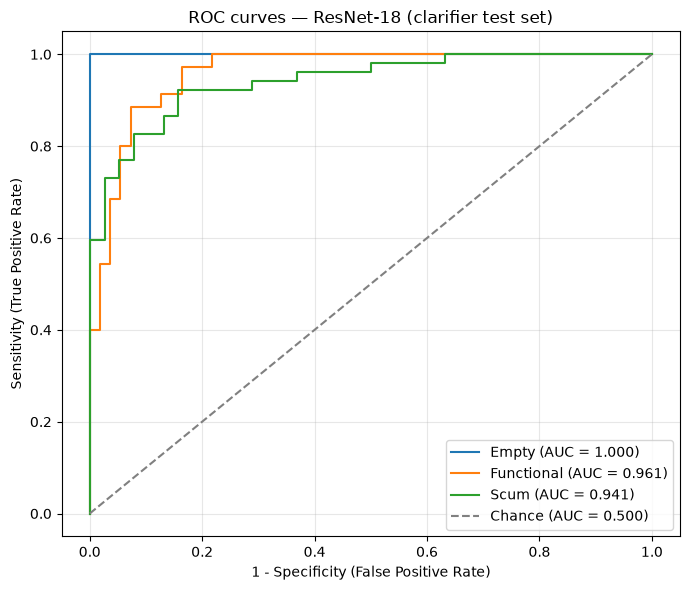

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 1.000
  Functional     : 0.961
  Scum           : 0.941

Mean AUC (over 3/4 classes with test examples): 0.967


(np.float64(0.7555555555555555),
 {'Dysfunctional': nan,
  'Empty': 1.0,
  'Functional': 0.9605194805194806,
  'Scum': 0.9412955465587044})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_Atlantis.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
